In [1]:
!pip install -q kaggle wandb onnx onnxruntime onnxscript
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 12.3 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/MLassignment4/MLassignment4/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d data
!ls -lh data

100% 285M/285M [00:15<00:00, 19.1MB/s]

total 667M
-rw-r--r-- 1 root root 7.1K Dec 11  2019 example_submission.csv
-rw-r--r-- 1 root root  92M Dec 11  2019 fer2013.tar.gz
-rw-r--r-- 1 root root 288M Dec 11  2019 icml_face_data.csv
-rw-r--r-- 1 root root  58M Dec 11  2019 test.csv
-rw-r--r-- 1 root root 230M Dec 11  2019 train.csv


In [3]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: smama23 (smama23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import copy
import torch
from torch import nn
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available:", device)

Device available: cuda


In [5]:
PROJECT = "fer2013-emotion-recognition"
EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

CONFIG = {
    "arch": "MobileNet-CNN",
    "epochs": 40,
    "batch_size": 64,
    "lr": 1e-3,
    "optimizer": "Adam",
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "augment": True,
    "scheduler": True,
    "patience": 8,
    "class_weights": False,
    "label_smoothing": 0.0,
    "width_mult": 1.0,
    "num_classes": 7,
}
CONFIG

{'arch': 'MobileNet-CNN',
 'epochs': 40,
 'batch_size': 64,
 'lr': 0.001,
 'optimizer': 'Adam',
 'weight_decay': 0.0001,
 'dropout': 0.3,
 'augment': True,
 'scheduler': True,
 'patience': 8,
 'class_weights': False,
 'label_smoothing': 0.0,
 'width_mult': 1.0,
 'num_classes': 7}

In [6]:
df = pd.read_csv("data/icml_face_data.csv")
df.columns = df.columns.str.strip()

def parse_pixels(series):
    return np.stack([np.array(p.split(), dtype=np.uint8).reshape(48, 48) for p in series])

def split_xy(frame):
    return parse_pixels(frame['pixels']), frame['emotion'].to_numpy(dtype=np.int64)

X_train, y_train = split_xy(df[df['Usage'] == 'Training'])
X_val,   y_val   = split_xy(df[df['Usage'] == 'PublicTest'])
X_test,  y_test  = split_xy(df[df['Usage'] == 'PrivateTest'])
print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (28709, 48, 48) | val: (3589, 48, 48) | test: (3589, 48, 48)


In [7]:
class FERDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images, self.labels, self.transform = images, labels, transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, i):
        return self.transform(Image.fromarray(self.images[i])), int(self.labels[i])


def build_transforms(augment):
    base = [transforms.ToTensor(), transforms.Normalize([0.5], [0.5])]
    if augment:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
        ] + base)
    return transforms.Compose(base)


def build_loaders(config):
    train_tf, eval_tf = build_transforms(config["augment"]), build_transforms(False)
    bs = config["batch_size"]
    return (
        DataLoader(FERDataset(X_train, y_train, train_tf), batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(FERDataset(X_val,   y_val,   eval_tf),  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(FERDataset(X_test,  y_test,  eval_tf),  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True),
    )

counts = np.bincount(y_train, minlength=7)
CLASS_WEIGHTS = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32)

In [8]:
class DSConv(nn.Module):
    """Depthwise-separable conv: depthwise 3x3 + pointwise 1x1 (each BN+ReLU)."""
    def __init__(self, cin, cout):
        super().__init__()
        self.dw = nn.Conv2d(cin, cin, 3, padding=1, groups=cin, bias=False)
        self.bn1 = nn.BatchNorm2d(cin)
        self.pw = nn.Conv2d(cin, cout, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.relu(self.bn1(self.dw(x)))
        x = self.relu(self.bn2(self.pw(x)))
        return x


class MobileNetMini(nn.Module):
    def __init__(self, num_classes=7, width_mult=1.0, dropout=0.3):
        super().__init__()
        ch = [max(8, int(c * width_mult)) for c in (32, 64, 128, 256)]
        self.stem = nn.Sequential(
            nn.Conv2d(1, ch[0], 3, padding=1, bias=False),
            nn.BatchNorm2d(ch[0]), nn.ReLU(inplace=True))
        self.body = nn.Sequential(
            DSConv(ch[0], ch[1]), nn.MaxPool2d(2),
            DSConv(ch[1], ch[2]), nn.MaxPool2d(2),
            DSConv(ch[2], ch[3]), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(ch[3], num_classes))
    def forward(self, x):
        return self.head(self.body(self.stem(x)))


def build_model(config):
    return MobileNetMini(num_classes=config["num_classes"],
                         width_mult=config["width_mult"], dropout=config["dropout"])

_m = build_model(CONFIG)
print("Trainable params:", sum(p.numel() for p in _m.parameters() if p.requires_grad))

Trainable params: 48519


In [9]:
model = build_model(CONFIG).to(device)
out = model(torch.randn(8, 1, 48, 48, device=device))
print("forward output shape:", out.shape); assert out.shape == (8, 7)
print("Forward check passed.")

forward output shape: torch.Size([8, 7])
Forward check passed.


In [10]:
model = build_model(CONFIG).to(device)
criterion = nn.CrossEntropyLoss(); optimizer = Adam(model.parameters(), lr=1e-3)
train_loader, val_loader, test_loader = build_loaders(CONFIG)
ob_x, ob_y = next(iter(train_loader)); ob_x, ob_y = ob_x[:32].to(device), ob_y[:32].to(device)
model.train()
for step in range(200):
    optimizer.zero_grad(); loss = criterion(model(ob_x), ob_y); loss.backward(); optimizer.step()
    if step % 40 == 0 or step == 199:
        acc = (model(ob_x).argmax(1) == ob_y).float().mean().item()
        print(f"step {step:3d} | loss {loss.item():.4f} | batch acc {acc:.2f}")
print("Backward check passed if loss -> ~0 and acc -> 1.0")

step   0 | loss 2.1012 | batch acc 0.16
step  40 | loss 0.3364 | batch acc 0.97
step  80 | loss 0.0422 | batch acc 1.00
step 120 | loss 0.0145 | batch acc 1.00
step 160 | loss 0.0138 | batch acc 1.00
step 199 | loss 0.0053 | batch acc 1.00
Backward check passed if loss -> ~0 and acc -> 1.0


In [11]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train: optimizer.zero_grad()
            logits = model(x); loss = criterion(logits, y)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item(); n += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def collect_preds(model, loader):
    model.eval(); preds, targets = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu()); targets.append(y)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

In [ ]:
def run_experiment(config, run_name):
    train_loader, val_loader, test_loader = build_loaders(config)
    run = wandb.init(project=PROJECT, name=run_name, group=config["arch"], config=config, reinit=True)

    model = build_model(config).to(device)
    wandb.watch(model, log="all", log_freq=200)
    weight = CLASS_WEIGHTS.to(device) if config.get("class_weights") else None
    criterion = nn.CrossEntropyLoss(weight=weight, label_smoothing=config.get("label_smoothing", 0.0))
    opt_cls = SGD if config["optimizer"] == "SGD" else Adam
    opt_kwargs = {"momentum": 0.9} if config["optimizer"] == "SGD" else {}
    optimizer = opt_cls(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"], **opt_kwargs)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3) if config["scheduler"] else None

    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    best_val_loss, best_val_acc, best_state, bad = float("inf"), 0.0, None, 0
    for epoch in range(config["epochs"]):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        if scheduler: scheduler.step(va_loss)
        best_val_acc = max(best_val_acc, va_acc)
        lr_now = optimizer.param_groups[0]["lr"]
        wandb.log({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                   "val_loss": va_loss, "val_acc": va_acc, "lr": lr_now})
        for k, v in zip(history, [tr_acc, va_acc, tr_loss, va_loss]): history[k].append(v)
        print(f"epoch {epoch+1:2d}/{config['epochs']} | train_loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val_loss {va_loss:.3f} acc {va_acc:.3f} | lr {lr_now:.1e}")
        if va_loss < best_val_loss - 1e-4:
            best_val_loss, best_state, bad = va_loss, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= config["patience"]:
                print(f"Early stopping at epoch {epoch+1} (no val-loss improvement for {bad}).")
                break
    if best_state is not None: model.load_state_dict(best_state)

    te_loss, te_acc = run_epoch(model, test_loader, criterion)
    preds, targets = collect_preds(model, test_loader)
    print(f"\nPrivateTest accuracy (best weights): {te_acc:.4f}")
    print(classification_report(targets, preds, target_names=EMOTIONS, digits=3))

    wandb.summary["test_acc"] = te_acc
    wandb.summary["test_loss"] = te_loss
    wandb.summary["best_val_acc"] = best_val_acc
    wandb.summary["epochs_run"] = len(history["train_acc"])
    wandb.summary["overfit_gap"] = max(history["train_acc"]) - best_val_acc
    wandb.summary["num_params"] = sum(p.numel() for p in model.parameters())
    wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(
        y_true=targets, preds=preds, class_names=EMOTIONS)})

    try:
        model_file = f"{run_name}.onnx"
        torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,
                          input_names=["input"], output_names=["logits"],
                          dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}}, dynamo=False)
    except Exception as e:
        print(f"ONNX export failed ({e}); saving .pth instead.")
        model_file = f"{run_name}.pth"; torch.save(model.state_dict(), model_file)
    art = wandb.Artifact(run_name, type="model", metadata={"test_acc": te_acc})
    art.add_file(model_file); run.log_artifact(art)

    wandb.unwatch(model)
    run.finish()
    return model, history, te_acc

In [13]:
model, history, test_acc = run_experiment(CONFIG, run_name="MobileNet-full-lr0.001-bs64")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch  1/40 | train_loss 1.770 acc 0.273 | val_loss 1.690 acc 0.325 | lr 1.0e-03
epoch  2/40 | train_loss 1.626 acc 0.356 | val_loss 1.540 acc 0.398 | lr 1.0e-03
epoch  3/40 | train_loss 1.521 acc 0.408 | val_loss 1.484 acc 0.425 | lr 1.0e-03
epoch  4/40 | train_loss 1.456 acc 0.439 | val_loss 1.395 acc 0.470 | lr 1.0e-03
epoch  5/40 | train_loss 1.408 acc 0.462 | val_loss 1.406 acc 0.476 | lr 1.0e-03
epoch  6/40 | train_loss 1.377 acc 0.475 | val_loss 1.325 acc 0.501 | lr 1.0e-03
epoch  7/40 | train_loss 1.349 acc 0.488 | val_loss 1.294 acc 0.517 | lr 1.0e-03
epoch  8/40 | train_loss 1.326 acc 0.493 | val_loss 1.340 acc 0.487 | lr 1.0e-03
epoch  9/40 | train_loss 1.298 acc 0.508 | val_loss 1.295 acc 0.524 | lr 1.0e-03
epoch 10/40 | train_loss 1.284 acc 0.512 | val_loss 1.274 acc 0.519 | lr 1.0e-03
epoch 11/40 | train_loss 1.269 acc 0.521 | val_loss 1.262 acc 0.528 | lr 1.0e-03
epoch 12/40 | train_loss 1.259 acc 0.523 | val_loss 1.277 acc 0.531 | lr 1.0e-03
epoch 13/40 | train_loss 1.2

/tmp/ipykernel_5631/765734239.py:52: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,████████████████████████▃▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▇▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▅▅▆▆▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███▇███████████
val_loss,█▆▆▄▅▄▃▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.58624
epoch,39
epochs_run,40
lr,0.00025
num_params,48519


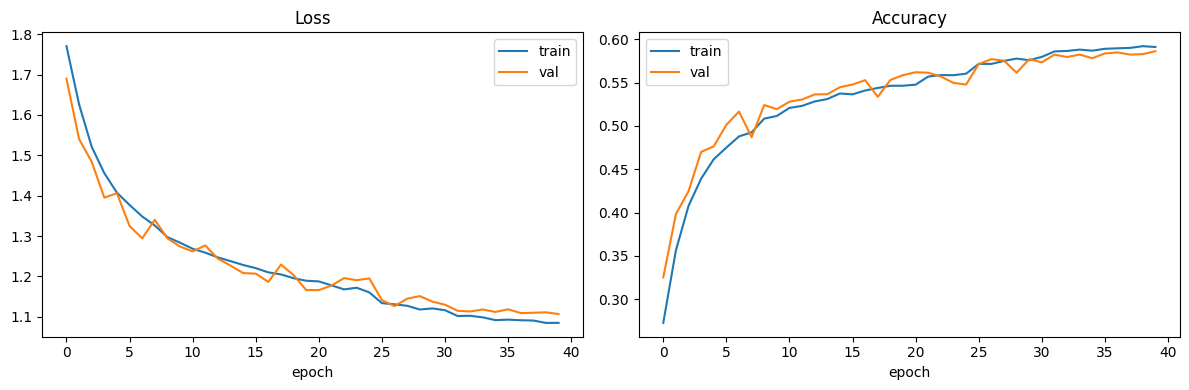

max train acc 0.592 | max val acc 0.586 | gap 0.006


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"max train acc {max(history['train_acc']):.3f} | max val acc {max(history['val_acc']):.3f} | "
      f"gap {max(history['train_acc']) - max(history['val_acc']):.3f}")

In [15]:
cfg_half = {**CONFIG, "width_mult": 0.5, "epochs": 30}
_, _, acc_half = run_experiment(cfg_half, run_name="MobileNet-width0.5")
print(f"full-width test {test_acc:.4f}  vs  half-width test {acc_half:.4f}")

epoch  1/30 | train_loss 1.791 acc 0.255 | val_loss 1.740 acc 0.291 | lr 1.0e-03
epoch  2/30 | train_loss 1.715 acc 0.303 | val_loss 1.661 acc 0.339 | lr 1.0e-03
epoch  3/30 | train_loss 1.636 acc 0.347 | val_loss 1.600 acc 0.371 | lr 1.0e-03
epoch  4/30 | train_loss 1.575 acc 0.379 | val_loss 1.542 acc 0.396 | lr 1.0e-03
epoch  5/30 | train_loss 1.536 acc 0.400 | val_loss 1.495 acc 0.428 | lr 1.0e-03
epoch  6/30 | train_loss 1.504 acc 0.416 | val_loss 1.461 acc 0.440 | lr 1.0e-03
epoch  7/30 | train_loss 1.467 acc 0.431 | val_loss 1.418 acc 0.459 | lr 1.0e-03
epoch  8/30 | train_loss 1.447 acc 0.442 | val_loss 1.413 acc 0.456 | lr 1.0e-03
epoch  9/30 | train_loss 1.421 acc 0.453 | val_loss 1.392 acc 0.474 | lr 1.0e-03
epoch 10/30 | train_loss 1.402 acc 0.463 | val_loss 1.373 acc 0.475 | lr 1.0e-03
epoch 11/30 | train_loss 1.394 acc 0.467 | val_loss 1.348 acc 0.495 | lr 1.0e-03
epoch 12/30 | train_loss 1.375 acc 0.471 | val_loss 1.335 acc 0.497 | lr 1.0e-03
epoch 13/30 | train_loss 1.3

/tmp/ipykernel_5631/765734239.py:52: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇███████████
train_loss,█▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██▇█████
val_loss,█▇▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁
best_val_acc,0.52549
epoch,29
epochs_run,30
lr,0.001
num_params,13511


full-width test 0.6052  vs  half-width test 0.5096


In [17]:
import wandb, torch
import pandas as pd, numpy as np
from torch.utils.data import DataLoader

try:
    wandb.unwatch(model)
except Exception:
    pass
for mod in model.modules():
    mod._forward_hooks.clear()
    mod._forward_pre_hooks.clear()
    mod._backward_hooks.clear()

test_df = pd.read_csv("data/test.csv")
X_kaggle = parse_pixels(test_df['pixels'])
kaggle_loader = DataLoader(FERDataset(X_kaggle, np.zeros(len(X_kaggle), np.int64), build_transforms(False)),
                           batch_size=128, shuffle=False)
kaggle_preds, _ = collect_preds(model, kaggle_loader)
pd.Series(kaggle_preds).to_csv("submission_mobilenet.csv", index=False, header=False)
print("Wrote submission_mobilenet.csv with", len(kaggle_preds), "predictions")


Wrote submission_mobilenet.csv with 7178 predictions
